In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [7]:
# Load iris dataset into numpy arrays features (X) and labels (y)

from sklearn.datasets import load_iris

X = load_iris().data
y = load_iris().target

In [8]:
X.shape

(150, 4)

In [9]:
pd.DataFrame(X).describe()

,0,1,2,3
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [10]:
pd.DataFrame(X).isna().sum()

0    0
1    0
2    0
3    0
dtype: int64

## Preprocessing

In [11]:
# Normalize data using StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [12]:
# Split to train and test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [13]:
X_train.shape

(112, 4)

In [14]:
X_test.shape

(38, 4)

## KNN

In [15]:
class KNN:
    def __init__(self, k):
        self.k = k
        self.X_train = None
        self.y_train = None

    # Compute the euclidean distance between two points
    def euclidean_dis(self, a, b):
        return np.sqrt(np.sum((a - b)**2))
    
    # Fit the model using X as training data and y as target values
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
    
    # Predict the output class for a single test sample
    def predict_single(self, X_test):
        distances = []
        for x in self.X_train:
            distances.append(self.euclidean_dis(x, X_test))
        distances = np.array(distances)

        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = self.y_train[k_indices]

        labels, counts = np.unique(k_nearest_labels, return_counts=True)
        most_common_labels = labels[np.argmax(counts)]

        return most_common_labels

    # Predict output class for a batch of test samples
    def predict(self, X):
        X = np.array(X)
        return [self.predict_single(x) for x in X]

In [16]:
# Compute the maximum value for k

k = int(np.sqrt(X.shape[0] / 2))
print(k)

8


In [17]:
# Train the knn model on the training data

from sklearn.metrics import accuracy_score

acc_values = []
k_values = range(2, k + 1)

for k in k_values:
    knn_model = KNN(k)
    knn_model.fit(X_train, y_train)

    # Predict values for the test datasets using trained model
    y_test_pred = knn_model.predict(X_test)
    
    # Evaluation metrics (calculate accuracy)
    acc = accuracy_score(y_test, y_test_pred)
    acc_values.append(acc)

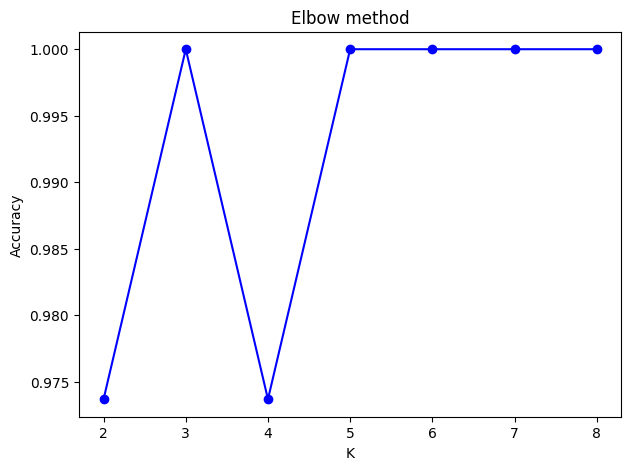

In [18]:
# Evaluation by elbow method

plt.figure(figsize=(7, 5))
plt.plot(k_values, acc_values, 'bo-')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Elbow method')
plt.show()

## Visualization

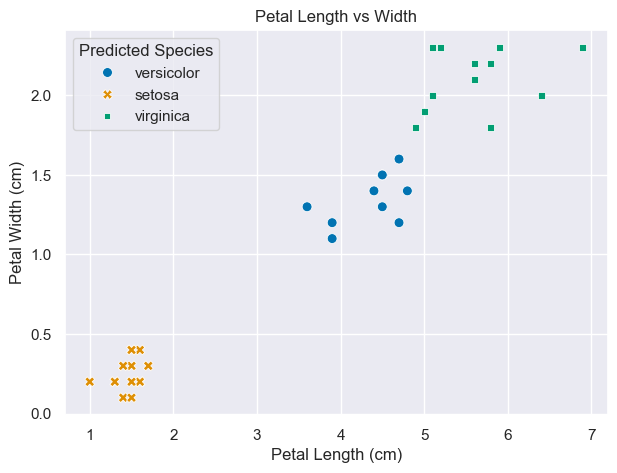

In [ ]:
# Plot petal length vs petal width colored by the predicted species

df_plot = pd.DataFrame(scaler.inverse_transform(X_test), columns=load_iris().feature_names)
df_plot['Predicted_Species'] = [load_iris().target_names[pred] for pred in y_test_pred]

plt.figure(figsize=(7, 5))
sns.set_theme(style="darkgrid")

sns.scatterplot(
    data=df_plot, 
    x='petal length (cm)', 
    y='petal width (cm)', 
    hue='Predicted_Species', 
    palette='colorblind', 
    style='Predicted_Species',
    s=50
)

plt.title('Petal Length vs Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Predicted Species')
plt.show()